# Replication of reskilling analysis from MSc thesis
Felix Zaussinger | 15.09.2022

**Core Analysis Goal(s)**
1. Replicate thesis approach based on updated data
2. Decide how to deal with skewed distribution when working with COOC matrix compared to ESCO matrix tables or Kanders Matrix
3. Understand and write down all of the assumptions that I make and reflect whether they are robust enough

**Key Insight(s)**
1.
2.
3.

In [2]:
import os
import scipy
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path

from mapping_career_causeways.compare_nodes_utils import find_closest

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context("paper", font_scale=1.5)
pd.options.display.float_format = '{:,.2f}'.format

# load paths
from src import utils
from src.data.framework import Esco
useful_paths = utils.UsefulPaths()

Define paths to lfs data

Read geodata with NUTS regions

In [3]:
gdf = gpd.read_file(os.path.join(useful_paths.data_raw, "geodata", "NUTS_RG_03M_2021_4326_LEVL_2", "NUTS_RG_03M_2021_4326_LEVL_2.shp"))

Zoom in on Germany

In [34]:
from src.data.lfs import EuLfs

# load config file of EU-LFS data
config = utils.load_config(
    os.path.join(useful_paths.config_dir, "eu_lfs_config.yml")
)

# create object
lfs = EuLfs(config=config)

df_all = lfs.read_preprocessed_file(
    year=2019,
    input_fname_lfs="eu_lfs_merged_{year}_with_final_unweighted_shares"
)

df_all["INCDECIL"] = df_all["INCDECIL"].astype(float)

In [35]:
df_de = df_all[df_all.COUNTRYW == "DE"]

earnings_deciles_de = pd.read_csv(os.path.join(useful_paths.data_raw, "metadata", "earnings_distribution_de_2016.csv"), delimiter=",").astype(float)

df_de = pd.merge(
    df_de,
    earnings_deciles_de,
    left_on="INCDECIL",
    right_on="decil",
    how="left"
)

## Occupation distance analysis

Notes
- occupation distance measure at ISCO 3D level (todo: aggregate from ESCO)
- additional covariates: income deciles, skill level as proxy for education, ...
- analysis will be slightly different than the Nesta approach

Questions
- calculate average skill profile of 3D groups is calculated from occ-skills matrix (not possible for Kanders matrix as I miss the input data)

Decision
- use self-calculated, weighted occ-skills matrix
- compute avg skills profiles at ISCO 3D level

In [6]:
%%time
from src.data.framework import Esco
esco = Esco()

# choose OSM version (weighted/unweighted)
osm_version = "weighted"

# read bipartite adjecency matrix for occupations and skills
osm = esco.read_occ_skills_matrix(return_version=osm_version)
osm_sparse = scipy.sparse.csr_matrix(osm.values)

# Co-occurrence matrix
W_sparse = osm_sparse.T.dot(osm_sparse)
W = W_sparse.toarray()
np.fill_diagonal(W,0)

CPU times: total: 4.03 s
Wall time: 4.64 s


In [8]:
%%time

# Read occupations with their ISCO level
occ = esco.occupations
occ["isco_3_digit"] = occ["iscoGroup"].astype(str).str.slice(stop=3)

# read raw occ-skills matrix

# choose OSM version (weighted/unweighted)
osm_version = "weighted"

# read bipartite adjecency matrix for occupations and skills
occ_skills_mat = esco.read_occ_skills_matrix(return_version=osm_version)

# Create multiindex
arrays = [occ.conceptUri.values, occ.isco_3_digit.values]
tuples = list(zip(*arrays))
index = pd.MultiIndex.from_tuples(tuples, names=["concept_uri", "isco_3_digit"])
assert np.alltrue(occ_skills_mat.index.values == occ.conceptUri.values)

# Aggregate original occ-skills matrix to ISCO 3-digit level
occ_skills_mat.index = index
occ_skills_mat_isco3 = occ_skills_mat.groupby(occ_skills_mat.index.get_level_values(1)).mean()

# Calculate occupation similarity matrix at ISCO 3-digit level
occ_sims_isco3 = np.matmul(occ_skills_mat_isco3.values, occ_skills_mat_isco3.values.transpose())

# Find labels for isco codes
isco_groups_labels = pd.merge(
    pd.DataFrame(data=occ_skills_mat_isco3.index.values.astype(str), columns=["code"]),
    esco.isco_groups[["code", "conceptUri", "preferredLabel"]],
    on="code",
    how="left"
)

arrays = [isco_groups_labels.conceptUri.values, isco_groups_labels.preferredLabel.values]
tuples = list(zip(*arrays))
index = pd.MultiIndex.from_tuples(tuples, names=["occ_uri", "occ"])

# to df
df_occ_sims = pd.DataFrame(index=index, columns=index, data=occ_sims_isco3)

CPU times: total: 3.73 s
Wall time: 4.36 s


In [9]:
similarity_matrix = df_occ_sims.copy().values
np.fill_diagonal(similarity_matrix, 0)

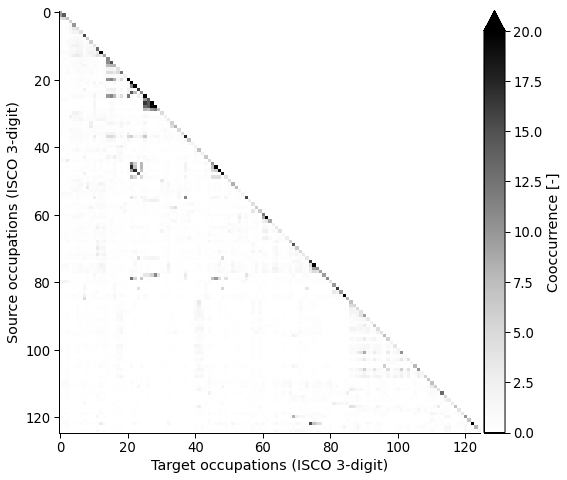

In [10]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(np.tril(df_occ_sims.values), cmap="Greys", vmax=20)

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im, cax=cax, orientation='vertical', label="Cooccurrence [-]", extend="max")
ax.set_ylabel("Source occupations (ISCO 3-digit)")
ax.set_xlabel("Target occupations (ISCO 3-digit)")

sns.despine()

Implement searching for closest occupation groups

In [11]:
df_occs = df_occ_sims.index.to_frame().reset_index(drop=True)

In [12]:
threatened_occs = {
    'Mining, manufacturing and construction supervisors': '312',
    'Mining and mineral processing plant operators': '811',
    'Manufacturing, mining, construction, and distribution managers': '132',
    'Mining and construction labourers': '931'
}

Manually check some transitions

In [48]:
# aggregating the shares by their mean yields the same shares because they dont differ within a 3-digit group
agg_dict = {
    "COEFF": np.sum, "INCDECIL": np.median, "share_green": np.mean,
    "share_brown_sl": np.mean, "share_neutral_sl": np.mean, "annual_earnings_2016": np.mean
}
isco3d_avg_de = df_de.groupby("ISCO3D_label").aggregate(agg_dict)

# define the GBN category of an ISCO 3D group as the one with the highest fraction (of ESCO occupations)
isco3d_avg_de["category"] = isco3d_avg_de[['share_green', 'share_brown_sl', 'share_neutral_sl']].idxmax(axis=1)
isco3d_avg_de = isco3d_avg_de.replace(to_replace={"category": {'share_green':'is_green', 'share_brown_sl': "is_brown", 'share_neutral_sl': "is_neutral"}})

# merge to df
df_occs_metadata = pd.merge(
    df_occs,
    isco3d_avg_de.reset_index(),
    left_on="occ",
    right_on="ISCO3D_label",
    how="left"
).drop(["ISCO3D_label"], axis=1)

Attach the categorical GBN classification to the LFS data

In [56]:
df_de = pd.merge(
    df_de,
    isco3d_avg_de.reset_index()[["ISCO3D_label", "category"]],
    on="ISCO3D_label",
    how="left"
)

In [39]:
occ = df_occs.loc[df_occs.occ == 'Mining and construction labourers']
print(occ.occ)

transitions = find_closest(
    i=occ.index.values[0],
    similarity_matrix=similarity_matrix,
    df=df_occs
)

transitions.head(5)

117    Mining and construction labourers
Name: occ, dtype: object


,occ_uri,occ,similarity
86,http://data.europa.eu/esco/isco/C711,Building frame and related trades workers,4.19
87,http://data.europa.eu/esco/isco/C712,Building finishers and related trades workers,3.34
112,http://data.europa.eu/esco/isco/C834,Mobile plant operators,3.05
41,http://data.europa.eu/esco/isco/C312,"Mining, manufacturing and construction supervi...",2.41
94,http://data.europa.eu/esco/isco/C741,Electrical equipment installers and repairers,1.42


In [40]:
df_de

,AGE,COEFF,COEFF_share_brown_sl,COEFF_share_brown_slt,COEFF_share_green,COEFF_share_neutral_sl,COEFF_share_neutral_slt,COUNTRY,COUNTRYW,DEGURBA,...,REGIONW,SEX,WSTATOR,share_brown_sl,share_brown_slt,share_green,share_neutral_sl,share_neutral_slt,decil,annual_earnings_2016
0,52,111.23,16.91,10.68,11.57,82.76,88.99,DE,DE,1,...,11,1,1,0.15,0.10,0.10,0.74,0.80,10.00,"55,368.00"
1,42,111.23,0.00,0.00,10.79,100.44,100.44,DE,DE,1,...,11,2,1,0.00,0.00,0.10,0.90,0.90,2.00,"11,970.00"
2,32,120.25,8.91,8.91,0.00,111.34,111.34,DE,DE,2,...,11,1,1,0.07,0.07,0.00,0.93,0.93,9.00,"34,299.00"
3,42,134.19,0.00,0.00,0.00,134.19,134.19,DE,DE,2,...,11,1,1,0.00,0.00,0.00,1.00,1.00,9.00,"34,299.00"
4,37,134.19,9.94,9.94,0.00,124.25,124.25,DE,DE,2,...,11,2,1,0.07,0.07,0.00,0.93,0.93,9.00,"34,299.00"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263969,32,141.34,0.00,0.00,0.00,141.34,141.34,DE,DE,2,...,G0,2,1,0.00,0.00,0.00,1.00,1.00,6.00,"22,243.00"
263970,27,141.34,0.00,0.00,0.00,141.34,141.34,DE,DE,2,...,G0,1,1,0.00,0.00,0.00,1.00,1.00,5.00,"19,692.00"
263971,37,133.32,20.27,12.80,13.87,99.19,106.66,DE,DE,3,...,G0,1,1,0.15,0.10,0.10,0.74,0.80,9.00,"34,299.00"
263972,32,130.30,4.42,2.21,0.00,125.88,128.09,DE,DE,3,...,G0,1,1,0.03,0.02,0.00,0.97,0.98,6.00,"22,243.00"


#### Aggregate to ISCO 3-digit level

Base the quantile on the respective quantiles of the viable/highly viable transition categories in the Kanders matrix
- Viable: 96th percentile
- Highly viable: 99th percentile

Viable/highly viable transitions
- Mining and mineral processing plant operators: 0
- Manufacturing, mining, construction, and distr: 2
- Mining, manufacturing and construction supervi: 1
- Mining and construction labourers: 8

In [41]:
q_viable = np.percentile(df_occ_sims.values.flatten(), q=96)
q_highly_viable = np.percentile(df_occ_sims.values.flatten(), q=99)

print(q_viable, q_highly_viable)

1.616368047779022 6.500853535353546


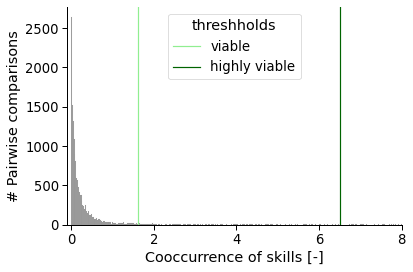

In [43]:
ax = sns.histplot(df_occ_sims.values.flatten(), color="grey")
ax.set_xlim(-0.1, 8)
ax.axvline(q_viable, color="lightgreen", label="viable")
ax.axvline(q_highly_viable, color="darkgreen", label="highly viable")
ax.set_ylabel("# Pairwise comparisons")
ax.set_xlabel("Cooccurrence of skills [-]")
plt.legend(loc="upper center", title="threshholds")
sns.despine()

Occupation similarity matrix classified viable/highly viable

In [44]:
similarity_matrix_classified = df_occ_sims.copy().values
np.fill_diagonal(similarity_matrix_classified, 0)

similarity_matrix_classified[similarity_matrix_classified < q_viable] = 0
similarity_matrix_classified[(similarity_matrix_classified >= q_viable) & (similarity_matrix_classified < q_highly_viable)] = 1
similarity_matrix_classified[similarity_matrix_classified >= q_highly_viable] = 2

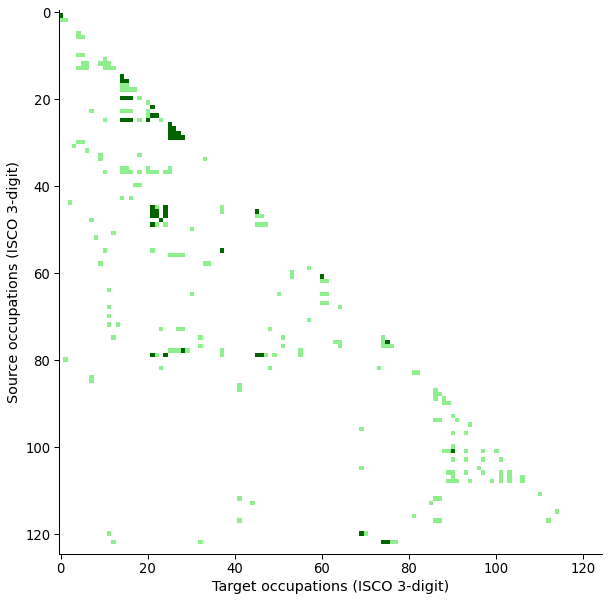

In [45]:
from matplotlib import colors

fig, ax = plt.subplots(figsize=(10, 10))

# make a color map of fixed colors
cmap = colors.ListedColormap(['white', 'lightgreen', 'darkgreen'])
bounds=[0,1,2,3]
norm = colors.BoundaryNorm(bounds, cmap.N)

im = ax.imshow(np.tril(similarity_matrix_classified), cmap=cmap, norm=norm)

ax.set_ylabel("Source occupations (ISCO 3-digit)")
ax.set_xlabel("Target occupations (ISCO 3-digit)")

sns.despine()

Zoom in on coal-related jobs

In [59]:
df_transition_pool = df_de.loc[df_de.category == "is_brown"]
df_transition_pool.COEFF.sum()

892402.4875

### Analyse number of viable transitions

In [60]:
cmap_earnings = plt.get_cmap("coolwarm_r", 16)
cmap_transitions = plt.get_cmap("Blues", 14)

# upper limits for colorbars
vmax_transitions = 14  # n viable transitions
vmax_wages = 40  # million euro

initialise dict to store estimates of total wage changes

In [61]:
earnings_losses = {}

#### Scenario 1: Workers follow closest viable transition regardless of earnings losses (Skills continuity scenario)

In [62]:
%%time
transition_number_data = []

for i, search_obs in df_transition_pool.iterrows():

    search_label = search_obs.ISCO3D_label
    idx = df_occs.loc[df_occs.occ == search_label].index.values[0]

    target_occs = find_closest(
        i=idx,
        similarity_matrix=similarity_matrix,
        df=df_occs_metadata
    )

    target_occs_filtered = target_occs.loc[target_occs.similarity > q_viable]
    target_occs_filtered = target_occs_filtered.loc[target_occs_filtered.category != "is_brown"]
    target_occs_filtered = target_occs_filtered.dropna()
    
    # earnings delta to next closest occupation
    target = target_occs_filtered.head(1)
    
    # check if viable transition exists
    if not target.empty:
        # Every worker transitions to the next-closest job and I evaluate the wage difference
        search_obs["earnings_delta_closest_switch"] = (target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016)
        search_obs["earnings_delta_closest_switch_sum"] = (target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016) * search_obs.COEFF
        search_obs["n_viable_transitions"] = target_occs_filtered.shape[0]
        search_obs["n_viable_transitions_sum"] = target_occs_filtered.shape[0] * search_obs.COEFF
        search_obs["transition_viable"] = True
        search_obs["transition_target"] = target.occ.values[0]
    else:
        # if no viable transition exists, I assume (FOR NOW), that the salary is lost entirely and has to be provided by the state (a bit unrealistic)
        search_obs["earnings_delta_closest_switch"] = search_obs.annual_earnings_2016 * (-1)
        search_obs["earnings_delta_closest_switch_sum"] = search_obs.annual_earnings_2016 * (-1) * search_obs.COEFF
        search_obs["n_viable_transitions"] = 0
        search_obs["n_viable_transitions_sum"] = 0
        search_obs["transition_viable"] = False
        search_obs["transition_target"] = None
    
    transition_number_data.append(search_obs)

# to df
df_transition_numbers = pd.concat(transition_number_data, axis=1).T
df_transition_numbers = df_transition_numbers.infer_objects()

# Calculate avg number of transitions per threatened job
df_transition_numbers_by_nuts = df_transition_numbers.groupby("NUTS_ID").sum()
df_transition_numbers_by_nuts["n_viable_transitions_rel"] = df_transition_numbers_by_nuts.n_viable_transitions_sum / df_transition_numbers_by_nuts.COEFF

# to gdf
gdf_transition_numbers_by_nuts = pd.merge(
    gdf.query("CNTR_CODE == 'DE'"),
    df_transition_numbers_by_nuts.reset_index(),
    on="NUTS_ID",
    how="left"
)

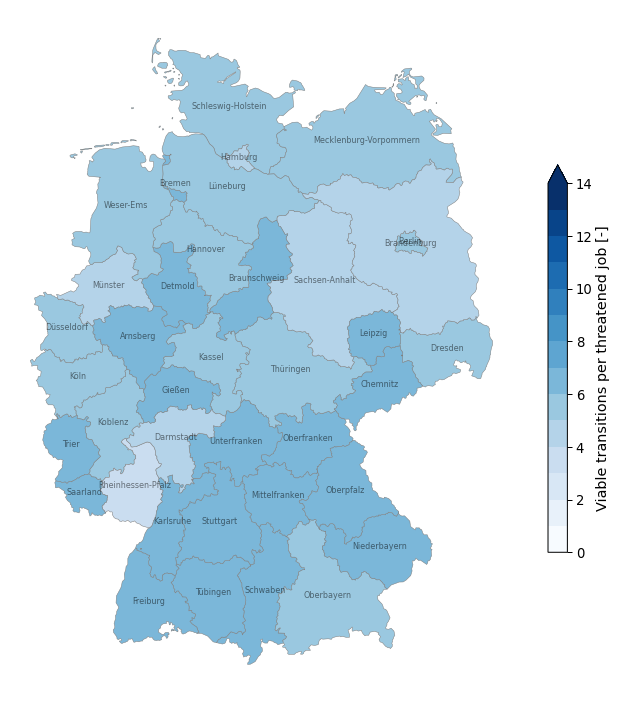

In [63]:
ax = gdf_transition_numbers_by_nuts.plot(column="n_viable_transitions_rel", figsize=(10, 10), legend=True, cmap=cmap_transitions, vmin=0, vmax=vmax_transitions, legend_kwds={"label": "Viable transitions per threatened job [-]", "fraction": 0.03, "extend":"max"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, edgecolor="grey", linewidth=0.5)
gdf_transition_numbers_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)

ax.axis('off')
plt.tight_layout()

#### Not sure if this makes sense...

risk = 1 / n_viable_transitions * n_at_risk_jobs

if n_viable_transitions = 0, ratio is set to 1

(5.4133400499999995, 15.49109895, 46.88094145, 55.44273755)

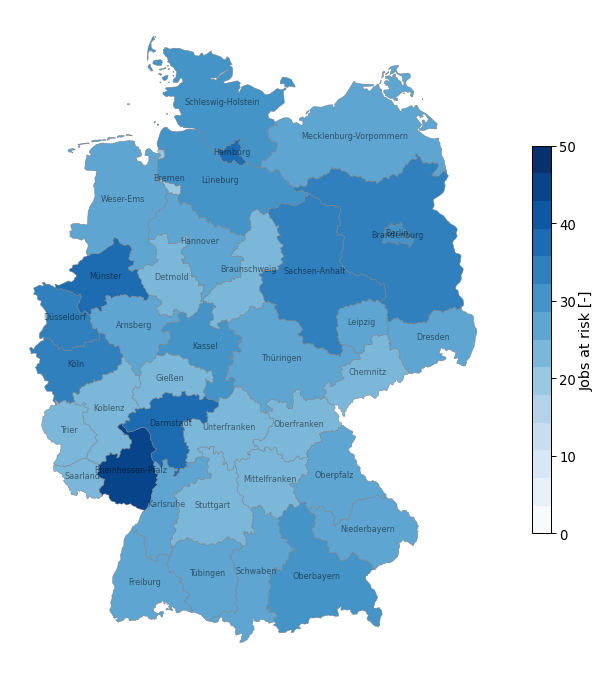

In [66]:
gdf_transition_numbers_by_nuts["risk_indicator"] = (1 / gdf_transition_numbers_by_nuts.n_viable_transitions).replace([np.inf, -np.inf], 1) * gdf_transition_numbers_by_nuts.COEFF

cmap = plt.get_cmap("Blues", 8)
ax = gdf_transition_numbers_by_nuts.plot(column="risk_indicator", figsize=(10, 10), legend=True, cmap=cmap_transitions, vmin=0, vmax=50, legend_kwds={"label": "Jobs at risk [-]", "fraction": 0.03}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, edgecolor="grey", linewidth=0.5)
gdf_transition_numbers_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)
plt.tight_layout()
ax.axis('off')

(5.4133400499999995, 15.49109895, 46.88094145, 55.44273755)

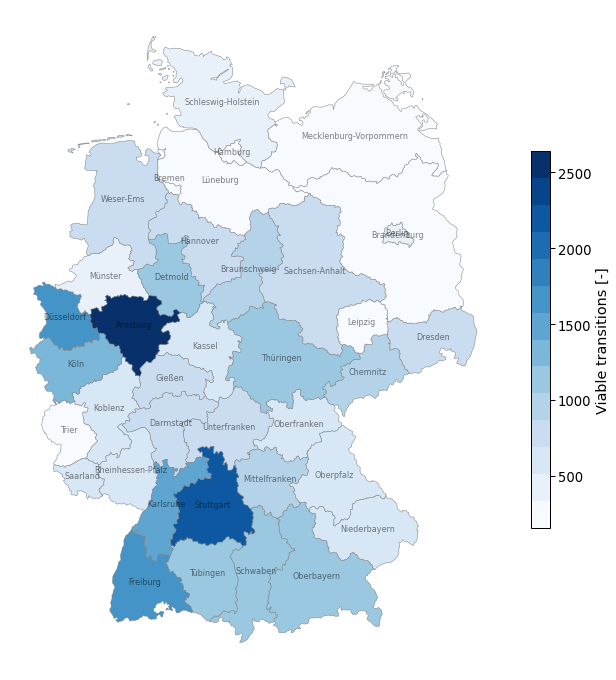

In [67]:
cmap = plt.get_cmap("Blues", 6)
ax = gdf_transition_numbers_by_nuts.plot(column="n_viable_transitions", figsize=(10, 10), legend=True, cmap=cmap_transitions, legend_kwds={"label": "Viable transitions [-]", "fraction": 0.03}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, edgecolor="grey", linewidth=0.5)
gdf_transition_numbers_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)
plt.tight_layout()
ax.axis('off')

Assumptions:
- every worker in the source occupation switches to the same target occupation

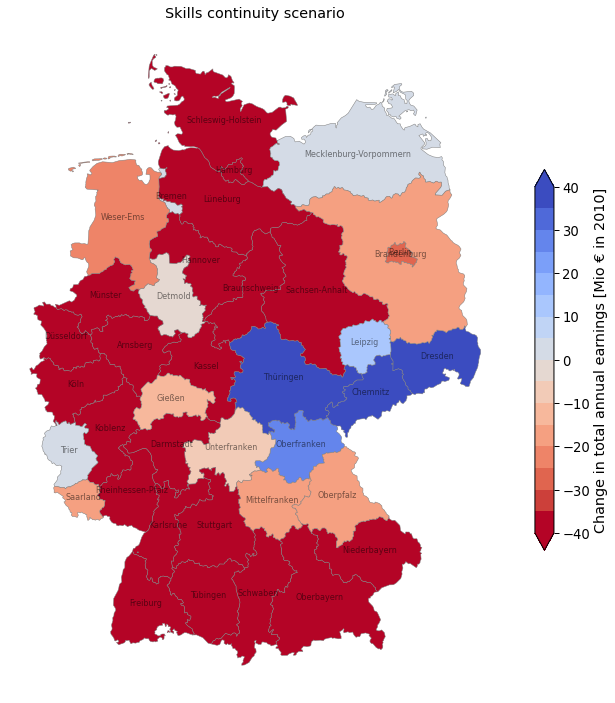

In [68]:
v = vmax_wages
gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] = gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] / 10**6
ax = gdf_transition_numbers_by_nuts.plot(column="earnings_delta_closest_switch_sum", figsize=(10, 10), legend=True, cmap=cmap_earnings, vmin=-v, vmax=v, legend_kwds={"label": "Change in total annual earnings [Mio € in 2010]", "fraction": 0.03, "extend":"both"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, edgecolor="grey", linewidth=0.5)
gdf_transition_numbers_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)

ax.set_title("Skills continuity scenario")
ax.axis('off')
plt.tight_layout()

Comparison of costs with Kohleaustiegsbudget

In [69]:
earnings_losses["skills_continuity"] = gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

print(np.abs(gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()) / (40 * 10**9))
gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

7.730279493961708e-08


-3092.1117975846832

#### Scenario 2: Workers follow viable transition that minimises earnings losses (wage continuity scenario)

In [70]:
%%time
transition_number_data = []

for i, search_obs in df_transition_pool.iterrows():
    search_label = search_obs.ISCO3D_label
    idx = df_occs.loc[df_occs.occ == search_label].index.values[0]
    
    target_occs = find_closest(
        i=idx,
        similarity_matrix=similarity_matrix,
        df=df_occs_metadata
    )
    
    # filter: viable, green or neutral
    target_occs_filtered = target_occs.loc[target_occs.similarity > q_viable]
    target_occs_filtered = target_occs_filtered.loc[target_occs_filtered.category != "is_brown"]
    target_occs_filtered = target_occs_filtered.dropna()
    
    # earnings delta to next closest occupation
    target_occs_filtered["wage_diff"] = target_occs_filtered.annual_earnings_2016 - search_obs.annual_earnings_2016
    
    # if I know the wage of the source occupation, choose transition that minimises wage losses
    if search_obs.annual_earnings_2016 != np.nan:
        target = target_occs_filtered.sort_values("wage_diff").tail(1)
    else:
        # if not, choose transition with highest target wage
        target = target_occs_filtered.sort_values("annual_earnings_2016").tail(1)
    
    # check if viable transition exists
    if not target.empty:
        # Every worker transitions to the next-closest job and I evaluate the wage difference
        search_obs["earnings_delta_closest_switch"] = (target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016)
        search_obs["earnings_delta_closest_switch_sum"] = (target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016) * search_obs.COEFF
        search_obs["n_viable_transitions"] = target_occs_filtered.shape[0]
        search_obs["n_viable_transitions_sum"] = target_occs_filtered.shape[0] * search_obs.COEFF
        search_obs["transition_viable"] = True
        search_obs["transition_target"] = target.occ.values[0]
    else:
        # if no viable transition exists, I assume (FOR NOW), that the salary is lost entirely and has to be provided by the state (a bit unrealistic)
        search_obs["earnings_delta_closest_switch"] = search_obs.annual_earnings_2016 * (-1)
        search_obs["earnings_delta_closest_switch_sum"] = search_obs.annual_earnings_2016 * (-1) * search_obs.COEFF
        search_obs["n_viable_transitions"] = 0
        search_obs["n_viable_transitions_sum"] = 0
        search_obs["transition_viable"] = False
        search_obs["transition_target"] = None
    
    transition_number_data.append(search_obs)
    
# to df
df_transition_numbers = pd.concat(transition_number_data, axis=1).T
df_transition_numbers = df_transition_numbers.infer_objects()

# Calculate avg number of transitions per threatened job
df_transition_numbers_by_nuts = df_transition_numbers.groupby("NUTS_ID").sum()
df_transition_numbers_by_nuts["n_viable_transitions_rel"] = df_transition_numbers_by_nuts.n_viable_transitions_sum / df_transition_numbers_by_nuts.COEFF

# to gdf
gdf_transition_numbers_by_nuts = pd.merge(
    gdf.query("CNTR_CODE == 'DE'"),
    df_transition_numbers_by_nuts.reset_index(),
    on="NUTS_ID",
    how="left"
)

CPU times: total: 23 s
Wall time: 23.4 s


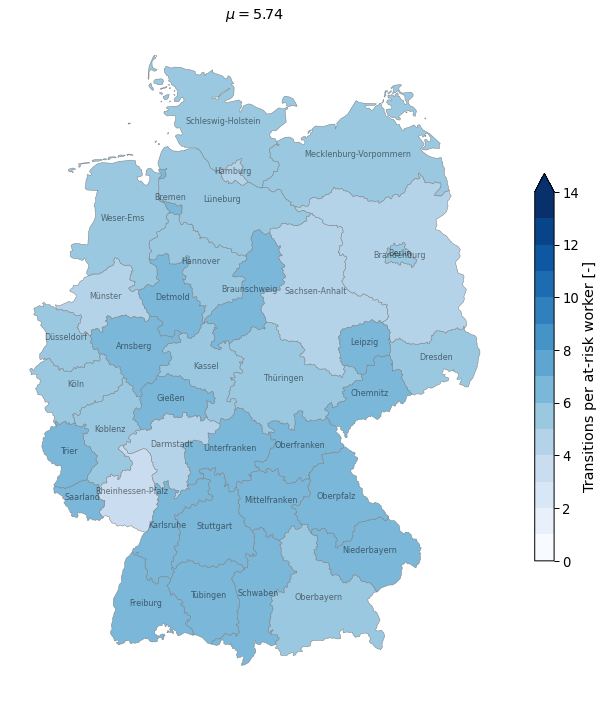

In [71]:
ax = gdf_transition_numbers_by_nuts.plot(column="n_viable_transitions_rel", figsize=(10, 10), legend=True, cmap=cmap_transitions, vmin=0, vmax=vmax_transitions, legend_kwds={"label": "Transitions per at-risk worker [-]", "fraction": 0.03, "extend":"max"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, edgecolor="grey", linewidth=0.5)
gdf_transition_numbers_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)


ax.set_title("$\mu = {:.2f}$".format(gdf_transition_numbers_by_nuts.n_viable_transitions_rel.mean()))
ax.axis('off')
plt.tight_layout()

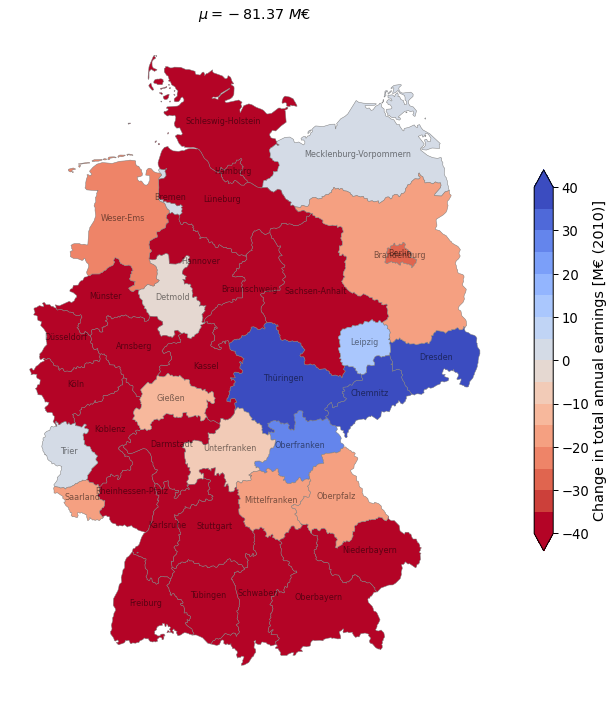

In [72]:
v = vmax_wages
gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] = gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] / 10**6
ax = gdf_transition_numbers_by_nuts.plot(column="earnings_delta_closest_switch_sum", figsize=(10, 10), legend=True, cmap=cmap_earnings, vmin=-v, vmax=v, legend_kwds={"label": "Change in total annual earnings [M€ (2010)]", "fraction": 0.03, "extend":"both"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, edgecolor="grey", linewidth=0.5)
gdf_transition_numbers_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)

ax.set_title("$\mu = {:.2f}~M€$".format(gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.mean()))
ax.axis('off')
plt.tight_layout()

Comparison of costs with Kohleaustiegsbudget

In [73]:
earnings_losses["wage_continuity"] = gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

print(np.abs(gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()) / (40 * 10**9))
gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

7.730279493961708e-08


-3092.1117975846832

## Upskilling analysis
- use stylised results from the upskilling analyis
- add skills that were found to unlock the most additional viable transitions per occupation to profile before calculating transitions
- pre-compute 4 different similarity matrices where those skills are already added

In [30]:
threatened_occs = {
    'Mining, manufacturing and construction supervisors': '312',
    'Mining and mineral processing plant operators': '811',
    'Manufacturing, mining, construction, and distribution managers': '132',
    'Mining and construction labourers': '931'
}

In [74]:
df_top_skills_per_occ = pd.read_csv(os.path.join(useful_paths.data_interim, "upskilling_analysis", "upskilling_best_5_skills_per_occupation.csv"), index_col=0)

if two skills unlock the same (top) number of new viable transitions, choose the one with the higher coreness

In [77]:
optimal_upskilling_per_occ = []
for group, df in df_top_skills_per_occ.groupby("Occupation"):
    # max new viable transitions
    t_max = df["Viable transitions"].max()
    sub_df = df[df["Viable transitions"] == t_max]
    
    # max coreness if multiple options
    c_max = sub_df["Coreness"].max()
    sub_sub_df = sub_df[sub_df["Coreness"] == c_max]
    optimal_upskilling_per_occ.append(sub_sub_df)
    
df_optimal_upskilling_per_occ = pd.concat(optimal_upskilling_per_occ, axis=0).reset_index(drop=True)

# get skill id
# todo: refactor to point to MCC repository
coreness = pd.read_csv(os.path.join(useful_paths.data_processed, "esco", "skills_network_metrics.csv"), index_col=0)

df_optimal_upskilling_per_occ = pd.merge(
    df_optimal_upskilling_per_occ,
    coreness.reset_index()[["index", "preferredLabel"]].rename(columns={"preferredLabel": "Skill", "index": "id_skill"}),
    on="Skill"
)

df_optimal_upskilling_per_occ["id_occ"] = [threatened_occs[occ_label] for occ_label in df_optimal_upskilling_per_occ.Occupation.values]

df_optimal_upskilling_per_occ.to_csv(os.path.join(useful_paths.data_interim, "upskilling_analysis", "upskilling_selected_skill_per_occupation.csv"))
df_optimal_upskilling_per_occ

,Occupation,Skill,Coreness,Viable transitions,id_skill,id_occ
0,"Manufacturing, mining, construction, and distr...",company policies,0.35,5,13398,132
1,Mining and construction labourers,troubleshoot,0.55,3,2834,931
2,Mining and mineral processing plant operators,quality standards,0.71,3,7737,811
3,"Mining, manufacturing and construction supervi...",quality standards,0.71,6,7737,312


In [78]:
occ_sims_isco3 = df_occ_sims.values
np.fill_diagonal(occ_sims_isco3, 0)

In [79]:
occ_codes = occ_skills_mat_isco3.index.values.tolist()

In [80]:
occ = df_optimal_upskilling_per_occ.iloc[0]

# find index of occ
idx_occ = occ_codes.index(occ.id_occ)
idx_new_skill = occ.id_skill

# add skill to occ skill profile
occ_skills_mat_isco3_upskilling = occ_skills_mat_isco3.copy()
occ_skills_mat_isco3_upskilling.iloc[idx_occ, idx_new_skill] = 1

# recalc occ sim matrix
occ_sims_isco3_upskilling = np.matmul(occ_skills_mat_isco3_upskilling.values, occ_skills_mat_isco3_upskilling.values.transpose())
np.fill_diagonal(occ_sims_isco3_upskilling, 0)

#### 1) Skills continuity scenario with upskilling

In [82]:
%%time
transition_number_data = []

for i, search_obs in df_transition_pool.iterrows():

    search_label = search_obs.ISCO3D_label
    idx = df_occs.loc[df_occs.occ == search_label].index.values[0]
    
    # -----------------------------------------------------------------------------------------------------------------------------
    # UPSKILLING STEP
    # -----------------------------------------------------------------------------------------------------------------------------
    # conditional on the source occupation, upskill worker with the skill unlocking the highest number of new viable transitions
    upskilling_data = df_optimal_upskilling_per_occ.loc[df_optimal_upskilling_per_occ.Occupation == search_label]

    # find index of occ
    idx_occ = occ_codes.index(upskilling_data.id_occ.values[0])
    idx_new_skill = upskilling_data.id_skill

    # add skill to occ skill profile
    occ_skills_mat_isco3_upskilling = occ_skills_mat_isco3.copy()
    occ_skills_mat_isco3_upskilling.iloc[idx_occ, idx_new_skill] = 1

    # recalc occ sim matrix
    occ_sims_isco3_upskilling = np.matmul(occ_skills_mat_isco3_upskilling.values, occ_skills_mat_isco3_upskilling.values.transpose())
    np.fill_diagonal(occ_sims_isco3_upskilling, 0)
    
    # find closest transitions
    target_occs = find_closest(
        i=idx,
        similarity_matrix=occ_sims_isco3_upskilling,
        df=df_occs_metadata
    )
    
    # filter
    target_occs_filtered = target_occs.loc[target_occs.similarity > q_viable]
    target_occs_filtered = target_occs_filtered.loc[target_occs_filtered.category != "is_brown"]
    target_occs_filtered = target_occs_filtered.dropna()
    
    # earnings delta to next closest occupation
    target = target_occs_filtered.head(1)
    
    # check if viable transition exists
    if not target.empty:
        # Every worker transitions to the next-closest job and I evaluate the wage difference
        search_obs["earnings_delta_closest_switch"] = (target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016)
        search_obs["earnings_delta_closest_switch_sum"] = (target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016) * search_obs.COEFF
        search_obs["n_viable_transitions"] = target_occs_filtered.shape[0]
        search_obs["n_viable_transitions_sum"] = target_occs_filtered.shape[0] * search_obs.COEFF
        search_obs["transition_viable"] = True
        search_obs["transition_target"] = target.occ.values[0]
    else:
        # if no viable transition exists, I assume (FOR NOW), that the salary is lost entirely and has to be provided by the state (a bit unrealistic)
        search_obs["earnings_delta_closest_switch"] = search_obs.annual_earnings_2016 * (-1)
        search_obs["earnings_delta_closest_switch_sum"] = search_obs.annual_earnings_2016 * (-1) * search_obs.COEFF
        search_obs["n_viable_transitions"] = 0
        search_obs["n_viable_transitions_sum"] = 0
        search_obs["transition_viable"] = False
        search_obs["transition_target"] = None
    
    transition_number_data.append(search_obs)

# to df
df_transition_numbers = pd.concat(transition_number_data, axis=1).T
df_transition_numbers = df_transition_numbers.infer_objects()

# Calculate avg number of transitions per threatened job
df_transition_numbers_by_nuts = df_transition_numbers.groupby("NUTS_ID").sum()
df_transition_numbers_by_nuts["n_viable_transitions_rel"] = df_transition_numbers_by_nuts.n_viable_transitions_sum / df_transition_numbers_by_nuts.COEFF

# to gdf
gdf_transition_numbers_by_nuts = pd.merge(
    gdf.query("CNTR_CODE == 'DE'"),
    df_transition_numbers_by_nuts.reset_index(),
    on="NUTS_ID",
    how="left"
)

IndexError: index 0 is out of bounds for axis 0 with size 0

(5.4133400499999995, 15.49109895, 46.88094145, 55.44273755)

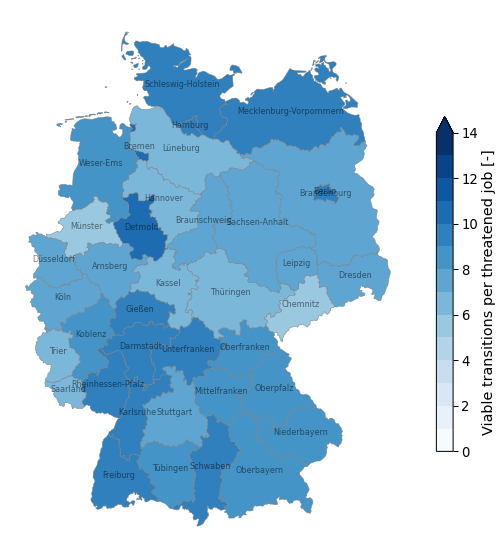

In [37]:
ax = gdf_transition_numbers_by_nuts.plot(column="n_viable_transitions_rel", figsize=(10, 10), legend=True, cmap=cmap_transitions, vmin=0, vmax=vmax_transitions, legend_kwds={"label": "Viable transitions per threatened job [-]", "fraction": 0.03, "extend":"max"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, edgecolor="grey", linewidth=0.5)
gdf_transition_numbers_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)

#ax.set_title("Viable transitions (upskilling)")
ax.axis('off')

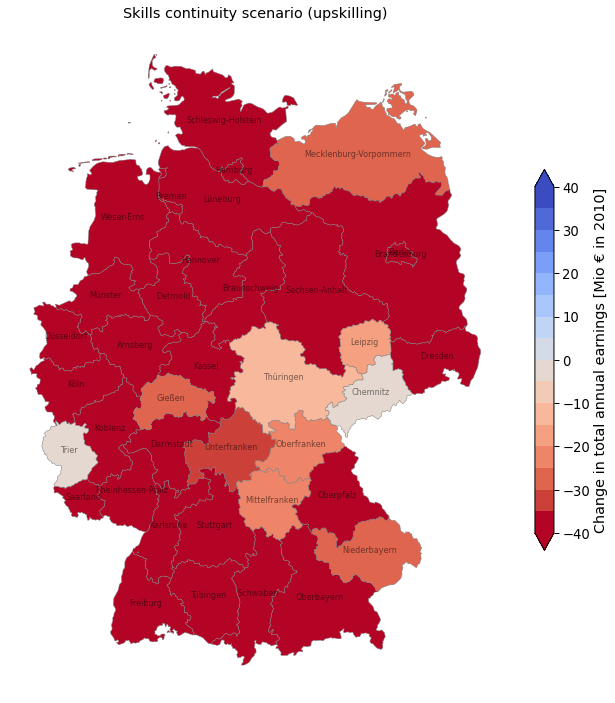

In [38]:
cmap = plt.get_cmap("RdYlGn")
v = vmax_wages
gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] = gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] / 10**6
ax = gdf_transition_numbers_by_nuts.plot(column="earnings_delta_closest_switch_sum", figsize=(10, 10), legend=True, cmap=cmap_earnings, vmin=-v, vmax=v, legend_kwds={"label": "Change in total annual earnings [Mio € in 2010]", "fraction": 0.03, "extend":"both"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, edgecolor="grey", linewidth=0.5)
gdf_transition_numbers_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)

ax.set_title("Skills continuity scenario (upskilling)")
ax.axis('off')
plt.tight_layout()

In [39]:
earnings_losses["skills_continuity_upskilling"] = gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

print(np.abs(gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()) / (40 * 10**9))
gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

7.265837120155642e-08


-2906.3348480622567

#### 2) Wage continuity scenario with upskilling

In [84]:
transition_number_data = []

for i, search_obs in df_transition_pool.iterrows():
    search_label = search_obs.ISCO3D_label
    idx = df_occs.loc[df_occs.occ == search_label].index.values[0]
    
    # -----------------------------------------------------------------------------------------------------------------------------
    # UPSKILLING STEP
    # -----------------------------------------------------------------------------------------------------------------------------
    # conditional on the source occupation, upskill worker with the skill unlocking the highest number of new viable transitions
    upskilling_data = df_optimal_upskilling_per_occ.loc[df_optimal_upskilling_per_occ.Occupation == search_label]

    # find index of occ
    idx_occ = occ_codes.index(upskilling_data.id_occ.values[0])
    idx_new_skill = upskilling_data.id_skill

    # add skill to occ skill profile
    occ_skills_mat_isco3_upskilling = occ_skills_mat_isco3.copy()
    occ_skills_mat_isco3_upskilling.iloc[idx_occ, idx_new_skill] = 1

    # recalc occ sim matrix
    occ_sims_isco3_upskilling = np.matmul(occ_skills_mat_isco3_upskilling.values, occ_skills_mat_isco3_upskilling.values.transpose())
    np.fill_diagonal(occ_sims_isco3_upskilling, 0)
    
    # find closest transitions
    target_occs = find_closest(
        i=idx,
        similarity_matrix=occ_sims_isco3_upskilling,
        df=df_occs_metadata
    )
    
    # filter: viable, green or neutral
    target_occs_filtered = target_occs.loc[target_occs.similarity > q_viable]
    target_occs_filtered = target_occs_filtered.loc[target_occs_filtered.category != "is_brown"]
    target_occs_filtered = target_occs_filtered.dropna()
    
    # earnings delta to next closest occupation
    target_occs_filtered["wage_diff"] = target_occs_filtered.annual_earnings_2016 - search_obs.annual_earnings_2016
    
    # if I know the wage of the source occupation, choose transition that minimises wage losses
    if search_obs.annual_earnings_2016 != np.nan:
        target = target_occs_filtered.sort_values("wage_diff").tail(1)
    else:
        # if not, choose transition with highest target wage
        target = target_occs_filtered.sort_values("annual_earnings_2016").tail(1)
    
    # check if viable transition exists
    if not target.empty:
        # Every worker transitions to the next-closest job and I evaluate the wage difference
        search_obs["earnings_delta_closest_switch"] = (target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016)
        search_obs["earnings_delta_closest_switch_sum"] = (target.annual_earnings_2016.values[0] - search_obs.annual_earnings_2016) * search_obs.COEFF
        search_obs["n_viable_transitions"] = target_occs_filtered.shape[0]
        search_obs["n_viable_transitions_sum"] = target_occs_filtered.shape[0] * search_obs.COEFF
        search_obs["transition_viable"] = True
        search_obs["transition_target"] = target.occ.values[0]
    else:
        # if no viable transition exists, I assume (FOR NOW), that the salary is lost entirely and has to be provided by the state (a bit unrealistic)
        search_obs["earnings_delta_closest_switch"] = search_obs.annual_earnings_2016 * (-1)
        search_obs["earnings_delta_closest_switch_sum"] = search_obs.annual_earnings_2016 * (-1) * search_obs.COEFF
        search_obs["n_viable_transitions"] = 0
        search_obs["n_viable_transitions_sum"] = 0
        search_obs["transition_viable"] = False
        search_obs["transition_target"] = None
    
    transition_number_data.append(search_obs)
    
# to df
df_transition_numbers = pd.concat(transition_number_data, axis=1).T
df_transition_numbers = df_transition_numbers.infer_objects()

# Calculate avg number of transitions per threatened job
df_transition_numbers_by_nuts = df_transition_numbers.groupby("NUTS_ID").sum()
df_transition_numbers_by_nuts["n_viable_transitions_rel"] = df_transition_numbers_by_nuts.n_viable_transitions_sum / df_transition_numbers_by_nuts.COEFF

# to gdf
gdf_transition_numbers_by_nuts = pd.merge(
    gdf.query("CNTR_CODE == 'DE'"),
    df_transition_numbers_by_nuts.reset_index(),
    on="NUTS_ID",
    how="left"
)

IndexError: index 0 is out of bounds for axis 0 with size 0

Transition numbers for "Wage continuity scenario (upskilling)" should be the same as for "Skills continuity scenario (upskilling)"

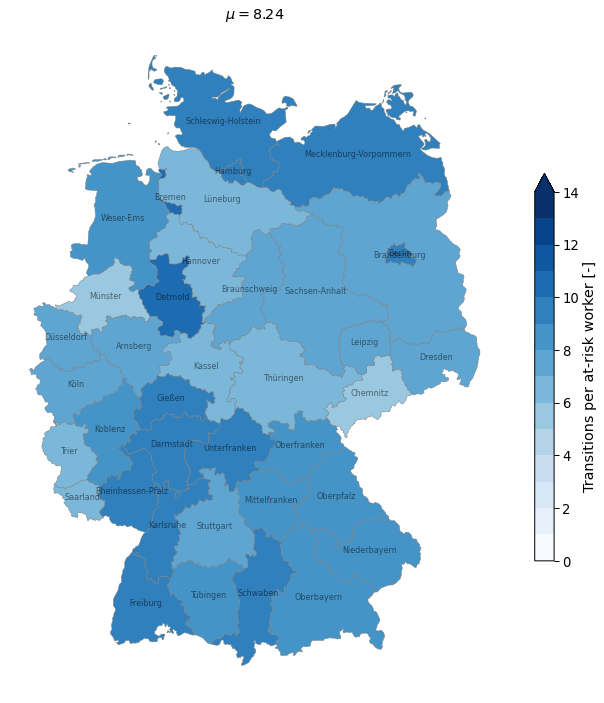

In [41]:
ax = gdf_transition_numbers_by_nuts.plot(column="n_viable_transitions_rel", figsize=(10, 10), legend=True, cmap=cmap_transitions, vmin=0, vmax=vmax_transitions, legend_kwds={"label": "Transitions per at-risk worker [-]", "fraction": 0.03, "extend":"max"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, edgecolor="grey", linewidth=0.5)
gdf_transition_numbers_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)


ax.set_title("$\mu = {:.2f}$".format(gdf_transition_numbers_by_nuts.n_viable_transitions_rel.mean()))
ax.axis('off')
plt.tight_layout()

-75.54267150484517

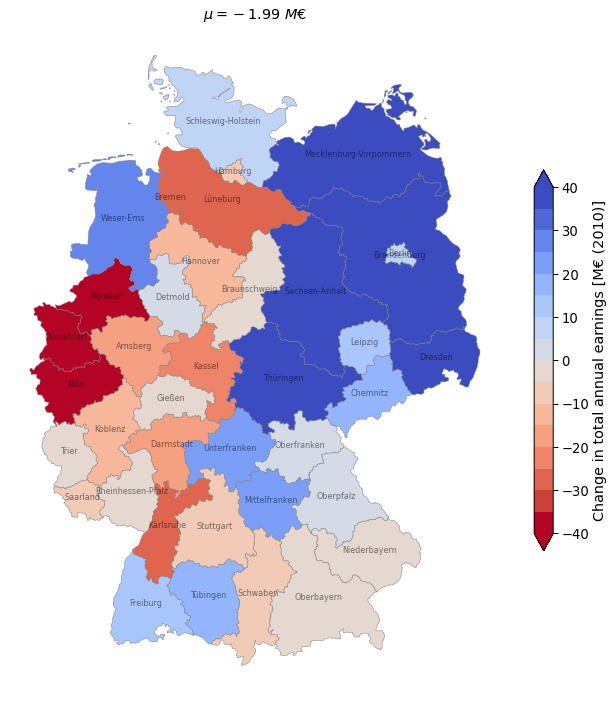

In [42]:
v = vmax_wages
gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] = gdf_transition_numbers_by_nuts["earnings_delta_closest_switch_sum"] / 10**6
ax = gdf_transition_numbers_by_nuts.plot(column="earnings_delta_closest_switch_sum", figsize=(10, 10), legend=True, cmap=cmap_earnings, vmin=-v, vmax=v, legend_kwds={"label": "Change in total annual earnings [M€ (2010)]", "fraction": 0.03, "extend":"both"}, missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"}, edgecolor="grey", linewidth=0.5)
gdf_transition_numbers_by_nuts.apply(lambda x: ax.annotate(text=x.NUTS_NAME, xy=x.geometry.centroid.coords[0], ha='center', alpha=0.5, rotation=0, fontsize=8), axis=1)

ax.set_title("$\mu = {:.2f}~M€$".format(gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.mean()))
ax.axis('off')

plt.tight_layout()

#plt.savefig(os.path.join(fpath_lfs, "felix", "figures", "earnings_losses_wage_continuity_upskilling.png"), dpi=300, bbox_inches="tight")

gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

In [43]:
earnings_losses["wage_continuity_upskilling"] = gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

print(np.abs(gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()) / (40 * 10**9))
gdf_transition_numbers_by_nuts.earnings_delta_closest_switch_sum.sum()

1.8885667876211293e-09


-75.54267150484517

#### Comparison of earnings losses across scenarios

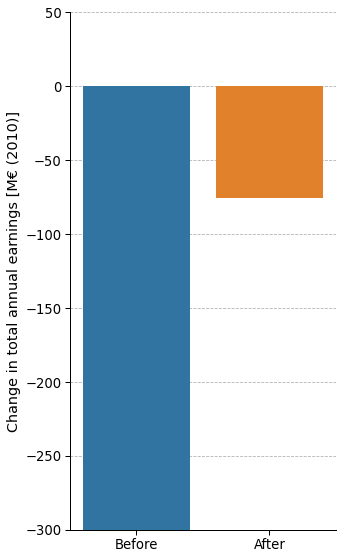

In [44]:
df_earnings_losses = pd.DataFrame.from_dict(earnings_losses, orient="index", columns=["annual_earnings_delta"])
df_earnings_losses.index.name = "scenario"
wage_scenario = df_earnings_losses.iloc[[1,3], :].reset_index()

fig, ax = plt.subplots(figsize=(5,8))
sns.barplot(
    data=wage_scenario,
    x="scenario",
    y="annual_earnings_delta",
    ax=ax,
    zorder=2,
)

sns.despine()

ax.set_xlabel(None)
ax.set_ylabel("Change in total annual earnings [M€ (2010)]")
ax.set_ylim(-300, 50)

plt.xticks(np.arange(2), ['Before', 'After'])
plt.grid(axis="y", linestyle="--", zorder=0)

plt.tight_layout()

# plt.savefig(os.path.join(fpath_lfs, "felix", "figures", "earnings_losses_wage_continuity_comparison.png"), dpi=300, bbox_inches="tight")

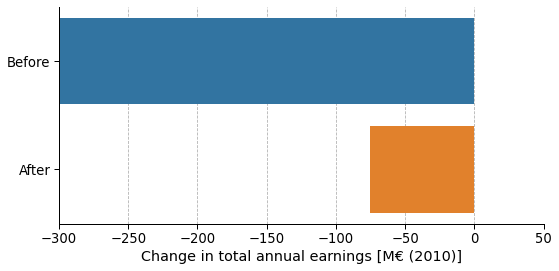

In [45]:
df_earnings_losses = pd.DataFrame.from_dict(earnings_losses, orient="index", columns=["annual_earnings_delta"])
df_earnings_losses.index.name = "scenario"
wage_scenario = df_earnings_losses.iloc[[1,3], :].reset_index()

fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(
    data=wage_scenario,
    y="scenario",
    x="annual_earnings_delta",
    ax=ax,
    zorder=2,
    orient="h"
)

sns.despine()

ax.set_ylabel(None)
ax.set_xlabel("Change in total annual earnings [M€ (2010)]")
ax.set_xlim(-300, 50.5)

plt.yticks(np.arange(2), ['Before', 'After'])
plt.grid(axis="x", linestyle="--", zorder=0)

plt.tight_layout()

# plt.savefig(os.path.join(fpath_lfs, "felix", "figures", "earnings_losses_wage_continuity_comparison_h.png"), dpi=300, bbox_inches="tight")

Pension in Germany with 67 years

In [46]:
median_age_coal_workers = 52
pension_age = 67
age_delta = pension_age - median_age_coal_workers

wage_scenario["earnings_delta_15yrs"] = wage_scenario.annual_earnings_delta * age_delta
wage_scenario

,scenario,annual_earnings_delta,earnings_delta_15yrs
0,wage_continuity,-2544.681170,-38170.217543
1,wage_continuity_upskilling,-75.542672,-1133.140073
